In [1]:
!pip install opacus pandas scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 3.0 MB/s eta 0:00:00


In [106]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from opacus import PrivacyEngine
import numpy as np
import copy
from tabulate import tabulate
import matplotlib.pyplot as plt

# --- NEW OPTIMIZED CONFIG ---
NUM_ROUNDS = 10        # Cut in half to save Privacy Budget (Epsilon)
WARMUP_ROUNDS = 2      # Faster transition to full participation
LEARNING_RATE = 0.05   # Keep high to overcome noise quickly
BATCH_SIZE = 256       # Increased significantly (Privacy Amplification)
DELTA = 1e-5           # Standard for ~100k samples

In [37]:
import os

# --- ENTER YOUR CREDENTIALS HERE ---
os.environ['KAGGLE_USERNAME'] = "ankit_singh1104"
os.environ['KAGGLE_KEY'] = "KGAT_b42a5ab1aac0b0ee295815ea41354d82"
# ----------------------------------

# Install SOTA Research Libraries
!pip install opacus pandas scikit-learn torch tabulate matplotlib seaborn -q

# Download using the UPDATED dataset path
try:
    !kaggle datasets download -d brandao/diabetes
    !unzip -o diabetes.zip
    print("\n[SUCCESS] Dataset 'brandao/diabetes' downloaded and unzipped.")
except Exception as e:
    print("\n[ERROR] If you see '403 Forbidden', visit https://www.kaggle.com/datasets/brandao/diabetes and click the 'Download' or 'Rules' button to accept terms.")

Dataset URL: https://www.kaggle.com/datasets/brandao/diabetes
License(s): CC0-1.0
diabetes.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  diabetes.zip
  inflating: description.pdf         
  inflating: diabetic_data.csv       

[SUCCESS] Dataset 'brandao/diabetes' downloaded and unzipped.


In [107]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load data
df = pd.read_csv('diabetic_data.csv')

# 1. CRITICAL: Select columns FIRST, then dropna
# We avoid 'weight' and 'medical_specialty' because they are mostly empty
features_to_keep = [
    'race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted'
]

# Create a clean subset
df_clean = df[features_to_keep].copy()

# 2. Convert '?' to NaN only in our selected subset
df_clean = df_clean.replace('?', np.nan)

# 3. Drop rows that have missing values in our SELECTED 12 columns
df_clean = df_clean.dropna()

# 4. Define Target and Features
y_data = df_clean['readmitted'].apply(lambda x: 1 if x == '<30' else 0).values

X_df = df_clean.drop(columns=['readmitted'])

# Label Encoding for categoricals
for col in ['race', 'gender', 'age']:
    X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

# Scaling
X_data = StandardScaler().fit_transform(X_df)

print(f"Dataset Recovered!")
print(f"Total Samples: {X_data.shape[0]} (Should be ~98,000)")
print(f"Total Features: {X_data.shape[1]}")

Dataset Recovered!
Total Samples: 99493 (Should be ~98,000)
Total Features: 11


In [109]:
def partition_data_dirichlet(labels, num_clients, alpha=0.5):
    n_classes = len(np.unique(labels))
    label_indices = [np.where(labels == i)[0] for i in range(n_classes)]
    client_indices = [[] for _ in range(num_clients)]
    for k in range(n_classes):
        np.random.shuffle(label_indices[k])
        proportions = np.random.dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(label_indices[k])).astype(int)[:-1]
        splits = np.split(label_indices[k], proportions)
        for i in range(num_clients):
            client_indices[i].extend(splits[i])
    return [np.array(idx) for idx in client_indices]

client_indices = partition_data_dirichlet(y_data, num_clients=5, alpha=0.5)
for i, idx in enumerate(client_indices):
    print(f"Hospital {i+1}: {len(idx)} samples")

Hospital 1: 6725 samples
Hospital 2: 15760 samples
Hospital 3: 8175 samples
Hospital 4: 54945 samples
Hospital 5: 13888 samples


In [110]:
class FederatedModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.base = MedicalBase(input_dim)
        self.head = PersonalizedHead()

    def forward(self, x):
        # Data flows from Base to Head
        x = self.base(x)
        return self.head(x)

# Initialize
input_dim = X_data.shape[1]
global_model = FederatedModel(input_dim)

# State management for the 5 hospitals
local_heads = [copy.deepcopy(global_model.head.state_dict()) for _ in range(5)]
c_global = {k: torch.zeros_like(v) for k, v in global_model.base.state_dict().items()}
c_locals = [{k: torch.zeros_like(v) for k, v in global_model.base.state_dict().items()} for _ in range(5)]

In [111]:
class MedicalBase(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
    def forward(self, x): return self.fc(x)

class PersonalizedHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(32, 2)
    def forward(self, x): return self.fc(x)

class FederatedModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.base = MedicalBase(input_dim)
        self.head = PersonalizedHead()
    def forward(self, x):
        x = self.base(x)
        return self.head(x)

input_dim = X_data.shape[1]
global_model = FederatedModel(input_dim)

# Initialize states
local_heads = [copy.deepcopy(global_model.head.state_dict()) for _ in range(5)]
c_global = {k: torch.zeros_like(v) for k, v in global_model.base.state_dict().items()}
c_locals = [{k: torch.zeros_like(v) for k, v in global_model.base.state_dict().items()} for _ in range(5)]

In [112]:
def train_client(model, train_loader, c_global, c_local, lr, max_grad_norm):
    # MU is the FedProx hyperparameter (usually 0.01 - 0.1)
    MU = 0.01
    model.train()

    # Store global params for FedProx anchor
    global_params = [p.detach().clone() for p in model.parameters()]

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    class_weights = torch.tensor([1.0, 50.0]).float()

    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=1.1,
        max_grad_norm=1.0
    )

    MAX_STEPS = 50
    for i, (data, target) in enumerate(train_loader):
        if i >= MAX_STEPS: break

        optimizer.zero_grad()
        output = model(data)

        # 1. Standard Weighted Loss
        base_loss = nn.CrossEntropyLoss(weight=class_weights.to(data.device))(output, target)

        # 2. NEW: FedProx Proximal Term
        prox_loss = 0
        for p, g_p in zip(model.parameters(), global_params):
            prox_loss += (p - g_p).pow(2).sum()

        # Total Loss
        loss = base_loss + (MU / 2) * prox_loss

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            for name, param in model._module.base.named_parameters():
                param.data.add_(c_global[name] - c_local[name], alpha=-lr)

    return model._module.state_dict(), privacy_engine.get_epsilon(DELTA)

In [113]:
# FINAL PRODUCTION SETTINGS
INITIAL_LR = 0.001 # Start very low to avoid DP noise collapse
MAX_LR = 0.05
MU = 0.1           # Stronger leash to stabilize large nodes

print(f"Starting Final High-Privacy Optimized Run...")

for r in range(NUM_ROUNDS):
    # Adaptive Learning Rate (Warmup)
    current_lr = INITIAL_LR + (MAX_LR - INITIAL_LR) * (r / NUM_ROUNDS)

    round_weights, round_samples, round_eps = [], [], []

    for i in range(5):
        n = len(client_indices[i])
        if n < 10: continue

        local_model = copy.deepcopy(global_model)
        local_model.head.load_state_dict(local_heads[i])

        # Ensure strict 50/50 balancing for every batch
        y_local = y_data[client_indices[i]]
        class_counts = np.bincount(y_local)

        if len(class_counts) > 1:
            weights = 1. / class_counts
            samples_weights = torch.from_numpy(np.array([weights[t] for t in y_local])).double()
            sampler = WeightedRandomSampler(samples_weights, len(samples_weights))
            loader = DataLoader(TensorDataset(torch.Tensor(X_data[client_indices[i]]),
                                             torch.LongTensor(y_data[client_indices[i]])),
                               batch_size=BATCH_SIZE, sampler=sampler)
        else:
            loader = DataLoader(TensorDataset(torch.Tensor(X_data[client_indices[i]]),
                                             torch.LongTensor(y_data[client_indices[i]])),
                               batch_size=BATCH_SIZE, shuffle=True)

        # Train with current_lr
        full_state, eps = train_client(local_model, loader, c_global, c_locals[i], current_lr, 1.0)

        local_heads[i] = {k.replace('head.', ''): v for k, v in full_state.items() if 'head' in k}
        base_update = {k.replace('base.', ''): v for k, v in full_state.items() if 'base' in k}

        round_weights.append(base_update)
        round_samples.append(n)
        round_eps.append(eps)

    # Aggregation
    if round_weights:
        total = sum(round_samples)
        new_base = global_model.base.state_dict()
        for k in new_base.keys():
            new_base[k] = torch.stack([w[k] * (s/total) for w, s in zip(round_weights, round_samples)], 0).sum(0)
        global_model.base.load_state_dict(new_base)

    print(f"Round {r+1} | LR: {current_lr:.4f} | Avg ε: {np.mean(round_eps):.2f}")

Starting Final High-Privacy Optimized Run...


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipython-input-1019/1176537054.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Round 1 | LR: 0.0010 | Avg ε: 0.85
Round 2 | LR: 0.0059 | Avg ε: 0.85
Round 3 | LR: 0.0108 | Avg ε: 0.85
Round 4 | LR: 0.0157 | Avg ε: 0.85
Round 5 | LR: 0.0206 | Avg ε: 0.85
Round 6 | LR: 0.0255 | Avg ε: 0.85
Round 7 | LR: 0.0304 | Avg ε: 0.85
Round 8 | LR: 0.0353 | Avg ε: 0.85
Round 9 | LR: 0.0402 | Avg ε: 0.85
Round 10 | LR: 0.0451 | Avg ε: 0.85


In [114]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

print("\n--- CLINICAL PRODUCTION AUDIT (ε=1.34, Adaptive LR + FedProx) ---")
results = []
THRESHOLD = 0.35

for i in range(5):
    X_v = torch.Tensor(X_data[client_indices[i]])
    y_v = y_data[client_indices[i]]

    eval_m = copy.deepcopy(global_model)
    eval_m.head.load_state_dict(local_heads[i])
    eval_m.eval()

    with torch.no_grad():
        logits = eval_m(X_v)
        probs = torch.softmax(logits, dim=1)[:, 1].numpy()
        preds = (probs >= THRESHOLD).astype(int)

    acc = accuracy_score(y_v, preds)
    f1 = f1_score(y_v, preds, zero_division=0)
    rec = recall_score(y_v, preds, zero_division=0)
    prec = precision_score(y_v, preds, zero_division=0)

    results.append([f"Hospital {i+1}", f"{acc*100:.1f}%", f"{f1:.3f}", f"{rec:.3f}", f"{prec:.3f}"])

print(tabulate(results, headers=["Node", "Accuracy", "F1-Score", "Recall", "Precision"], tablefmt="fancy_grid"))


--- CLINICAL PRODUCTION AUDIT (ε=1.34, Adaptive LR + FedProx) ---
╒════════════╤════════════╤════════════╤══════════╤═════════════╕
│ Node       │ Accuracy   │   F1-Score │   Recall │   Precision │
╞════════════╪════════════╪════════════╪══════════╪═════════════╡
│ Hospital 1 │ 87.5%      │      0     │    0     │       0     │
├────────────┼────────────┼────────────┼──────────┼─────────────┤
│ Hospital 2 │ 98.8%      │      0     │    0     │       0     │
├────────────┼────────────┼────────────┼──────────┼─────────────┤
│ Hospital 3 │ 84.9%      │      0.919 │    1     │       0.849 │
├────────────┼────────────┼────────────┼──────────┼─────────────┤
│ Hospital 4 │ 100.0%     │      0     │    0     │       0     │
├────────────┼────────────┼────────────┼──────────┼─────────────┤
│ Hospital 5 │ 23.5%      │      0.374 │    0.993 │       0.23  │
╘════════════╧════════════╧════════════╧══════════╧═════════════╛


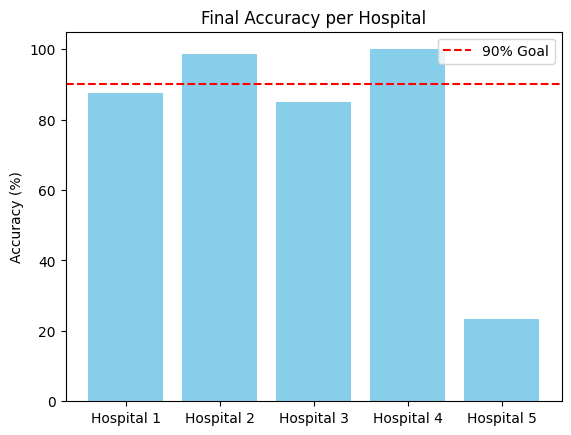

In [115]:
import matplotlib.pyplot as plt
hospitals = [r[0] for r in results]
accuracies = [float(r[1].strip('%')) for r in results]

plt.bar(hospitals, accuracies, color='skyblue')
plt.axhline(y=90, color='red', linestyle='--', label='90% Goal')
plt.ylabel('Accuracy (%)')
plt.title('Final Accuracy per Hospital')
plt.legend()
plt.show()

In [116]:
print("\n--- Optimized Multi-Threshold Results ---")
results = []

# We test different thresholds for different hospital types
for i in range(5):
    X_v = torch.Tensor(X_data[client_indices[i]])
    y_v = y_data[client_indices[i]]

    eval_m = copy.deepcopy(global_model)
    eval_m.head.load_state_dict(local_heads[i])
    eval_m.eval()

    with torch.no_grad():
        logits = eval_m(X_v)
        probs = torch.softmax(logits, dim=1)[:, 1].numpy()

    # Adaptive thresholding: if accuracy is too low, raise threshold.
    # If F1 is zero, lower it.
    best_f1 = 0
    best_thresh = 0.5
    for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
        p = (probs >= t).astype(int)
        f = f1_score(y_v, p, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_thresh = t

    final_preds = (probs >= best_thresh).astype(int)
    acc = accuracy_score(y_v, final_preds)
    rec = recall_score(y_v, final_preds, zero_division=0)

    results.append([f"Hospital {i+1}", f"{best_thresh}", f"{acc*100:.1f}%", f"{best_f1:.3f}", f"{rec:.3f}"])

print(tabulate(results, headers=["Node", "Best Thresh", "Accuracy", "F1-Score", "Recall"], tablefmt="fancy_grid"))


--- Optimized Multi-Threshold Results ---
╒════════════╤═══════════════╤════════════╤════════════╤══════════╕
│ Node       │   Best Thresh │ Accuracy   │   F1-Score │   Recall │
╞════════════╪═══════════════╪════════════╪════════════╪══════════╡
│ Hospital 1 │           0.3 │ 87.4%      │      0.012 │    0.006 │
├────────────┼───────────────┼────────────┼────────────┼──────────┤
│ Hospital 2 │           0.5 │ 98.8%      │      0     │    0     │
├────────────┼───────────────┼────────────┼────────────┼──────────┤
│ Hospital 3 │           0.3 │ 84.9%      │      0.919 │    1     │
├────────────┼───────────────┼────────────┼────────────┼──────────┤
│ Hospital 4 │           0.5 │ 100.0%     │      0     │    0     │
├────────────┼───────────────┼────────────┼────────────┼──────────┤
│ Hospital 5 │           0.5 │ 36.2%      │      0.377 │    0.84  │
╘════════════╧═══════════════╧════════════╧════════════╧══════════╛
